# Notebook 05 — Modeling: Project-Level (Operational / Per-Grant Estimation)
**Label:** `log_federal_share` (log1p of federalShareObligated per project)
**Use case:** Local recovery coordinators sanity-checking individual project grant estimates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../')
from utils import regression_metrics

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

PROCESSED = '../data/processed/'
proj = pd.read_csv(PROCESSED + 'cleaned_project_level.csv', low_memory=False)
print('Project-level shape:', proj.shape)
proj.head(3)


Project-level shape: (809734, 33)


,disasterNumber,declarationDate,incidentType,pwNumber,applicationTitle,applicantId,damageCategoryCode,damageCategoryDescrip,projectStatus,projectProcessStep,...,poverty_rate,population,risk_score,risk_rating,declaration_lag_days,incident_duration_days,incident_season,incident_year,prior_disasters_5yr,log_federal_share
0,1239,1998-08-26 00:00:00+00:00,Severe Storm(s),1,(PW# 1) IMMEDIATE NEEDS FUNDING,465-19792-00,B,Emergency Protective Measures,Active,Project Closed Out,...,20.3,47488.0,76.081425,Relatively Low,4,9,Summer,1998,0,11.225257
1,1239,1998-08-26 00:00:00+00:00,Severe Storm(s),5,(PW# 5) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,...,20.3,47488.0,76.081425,Relatively Low,4,9,Summer,1998,0,9.600024
2,1239,1998-08-26 00:00:00+00:00,Severe Storm(s),7,(PW# 7) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,...,20.3,47488.0,76.081425,Relatively Low,4,9,Summer,1998,0,9.882481


## 5.1 Define Features & Target
Note: `damageCategoryCode` is included here (not in disaster-level model) — it's known per-project.


In [2]:
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'damageCategoryCode', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
TARGET = 'log_federal_share'

CAT_FEATURES = [c for c in CAT_FEATURES if c in proj.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in proj.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

df_model = proj[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')


Modeling rows: 809,734  |  Features: 11


## 5.2 Time-Based Train / Test Split


In [3]:
SPLIT_YEAR = 2018
train = df_model[df_model['incident_year'] <  SPLIT_YEAR]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')


Train: 654,534  |  Test: 155,200


## 5.3 Train & Evaluate Models


In [4]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])

models = {
    'Baseline (Mean)':  DummyRegressor(strategy='mean'),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest':    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results_project = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    m = regression_metrics(y_test.values, preds, label=name)
    m['pipeline'] = pipe
    m['preds']    = preds
    results_project[name] = m



  Baseline (Mean)
  MAE  :     1.8965
  RMSE :     2.4781
  R²   :    -0.5182
  MAPE :     16.61%

  Ridge Regression
  MAE  :     1.8188
  RMSE :     2.2921
  R²   :    -0.2988
  MAPE :     17.24%

  Random Forest
  MAE  :     1.8788
  RMSE :     2.4163
  R²   :    -0.4435
  MAPE :     16.92%


## 5.4 Results Summary Table


In [5]:
summary = pd.DataFrame([
    {k: v for k, v in v.items() if k not in ('pipeline', 'preds')}
    for v in results_project.values()
]).set_index('label')
summary


,MAE,RMSE,R2,MAPE
label,,,,
Baseline (Mean),1.896507,2.478088,-0.518195,16.614267
Ridge Regression,1.818770,2.292087,-0.298842,17.236234
Random Forest,1.878833,2.416332,-0.443468,16.921508


## 5.5 Feature Importances — Random Forest


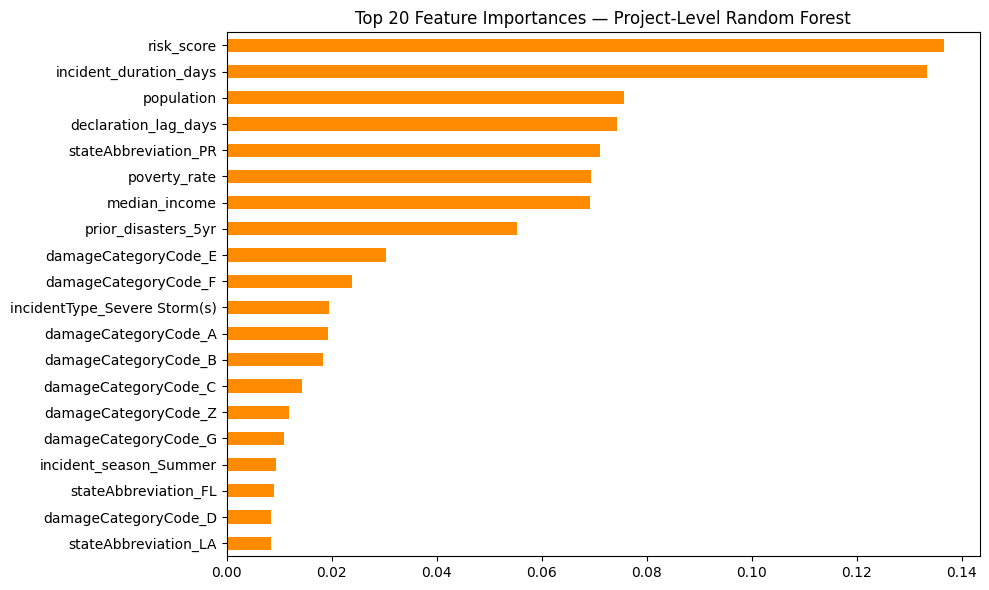

In [6]:
rf_pipe  = results_project['Random Forest']['pipeline']
rf_model = rf_pipe.named_steps['model']
rf_pre   = rf_pipe.named_steps['pre']

ohe_names = rf_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names = list(ohe_names) + NUM_FEATURES

importances = pd.Series(rf_model.feature_importances_, index=all_names)
importances.nlargest(20).sort_values().plot(
    kind='barh', figsize=(10, 6),
    title='Top 20 Feature Importances — Project-Level Random Forest',
    color='darkorange'
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_project.png', dpi=150)
plt.show()


## 5.6 Save Best Pipeline


In [7]:
best_name = max(results_project, key=lambda k: results_project[k]['R2'])
print(f'Best model: {best_name}  (R² = {results_project[best_name]["R2"]:.4f})')

with open(PROCESSED + 'best_project_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     results_project[best_name]['pipeline'],
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_project[best_name]['preds'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'model_name':   best_name,
    }, f)
print('Saved best_project_model.pkl')


Best model: Ridge Regression  (R² = -0.2988)
Saved best_project_model.pkl
